In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pathlib import Path

from nbqol import path_to_git_root
ROOT = Path(path_to_git_root()) # automatically makes path to repo directory (wherever you cloned it)
RAW_DATA = ROOT / "QPCR" / "data"
OUTPUT = ROOT / "QPCR" / "outs"

print("Repository directory: ", ROOT)

Repository directory:  /Users/timothy/Documents/GitHub/mouse-models


In [7]:
qPCR_data = pd.read_csv(RAW_DATA / "MP1_P_qpcr_B-B1-U-U1.csv")
bulkRNA_data = pd.read_csv(RAW_DATA / "MP1_P_bulkrnaseq_B-B1-U-U1.csv")

In [8]:
def calculate_ddct(df, goi, hkg, reference_sample, test_sample):
    """
    Calculate 2^-ΔΔCt for qPCR data.

    Parameters:
        df               : DataFrame with columns [Sample Name, Target Name, CT]
        goi              : Gene of interest, string, case-insensitive
        hkg              : Housekeeping gene string OR list of housekeeping genes
        reference_sample : Reference/control sample name
        test_sample      : Test sample name

    Returns:
        final 2^-ΔΔCt
    """

    df = df.copy()

    # Normalize columns
    df['Target Name'] = df['Target Name'].astype(str).str.lower().str.strip()
    df['Sample Name'] = df['Sample Name'].astype(str).str.strip()

    goi = goi.lower().strip()
    reference_sample = reference_sample.strip()
    test_sample = test_sample.strip()

    # Allow hkg to be a string or a list
    if isinstance(hkg, str):
        hkg_list = [hkg.lower().strip()]
    else:
        hkg_list = [gene.lower().strip() for gene in hkg]

    # Replace 'Undetermined' or bad CT values with NaN
    df['CT'] = pd.to_numeric(df['CT'], errors='coerce')

    def mean_ct(sample, target):
        vals = df[
            (df['Sample Name'] == sample) &
            (df['Target Name'] == target)
        ]['CT']

        if vals.empty:
            raise ValueError(f"No CT values found for {sample} / {target}")

        if vals.isna().all():
            raise ValueError(f"All CT values are Undetermined for {sample} / {target}")

        return vals.mean()

    def mean_hkg_ct(sample):
        """
        Average the mean CT of each housekeeping gene.
        This prevents a housekeeping gene with more replicates from being weighted more heavily.
        """
        hkg_means = [mean_ct(sample, gene) for gene in hkg_list]
        return np.mean(hkg_means)

    # Average CT values
    ct_goi_ref = mean_ct(reference_sample, goi)
    ct_goi_test = mean_ct(test_sample, goi)

    ct_hkg_ref = mean_hkg_ct(reference_sample)
    ct_hkg_test = mean_hkg_ct(test_sample)

    # ΔCt = CT(GOI) - CT(HKG average)
    dct_reference = ct_goi_ref - ct_hkg_ref
    dct_test = ct_goi_test - ct_hkg_test

    # ΔΔCt = ΔCt(test) - ΔCt(reference)
    ddct = dct_test - dct_reference

    # 2^-ΔΔCt
    expression = 2 ** (-ddct)

    return expression

In [9]:
def plot_qpcr_vs_rnaseq_mice(
    qpcr_df,
    rnaseq_df,
    hkg,
    reference_sample,
    test_sample,
    color1='steelblue',
    color2='salmon',
    genes_to_include=None
):
    """
    Plots grouped bars comparing qPCR log2FC vs RNAseq log2FC for each target gene.
    Parameters:
        qpcr_df          : qPCR DataFrame [Sample Name, Target Name, CT]
        rnaseq_df        : RNAseq DataFrame with Gene column + comparison columns as headers
        hkg              : Housekeeping gene or list of housekeeping genes (case-insensitive)
        reference_sample : Reference sample name
        test_sample      : Test sample name
        color1           : Bar color for qPCR
        color2           : Bar color for RNAseq
        genes_to_include : Optional list of genes to plot, in given order
    """
    comparison = f"{test_sample} vs {reference_sample}"
    if comparison not in rnaseq_df.columns:
        raise ValueError(
            f"Column '{comparison}' not found in RNAseq data. "
            f"Available: {list(rnaseq_df.columns)}"
        )

    # --- Clean qPCR ---
    qpcr_df = qpcr_df.copy()
    qpcr_df['Target Name'] = qpcr_df['Target Name'].str.lower().str.strip()
    qpcr_df['Sample Name'] = qpcr_df['Sample Name'].str.strip()
    qpcr_df['CT'] = pd.to_numeric(qpcr_df['CT'], errors='coerce')

    # --- Normalize hkg to list ---
    if isinstance(hkg, str):
        hkg_list = [hkg.lower().strip()]
    else:
        hkg_list = [g.lower().strip() for g in hkg]
    if not hkg_list:
        raise ValueError("At least one housekeeping gene must be provided.")
    hkg_set = set(hkg_list)

    qpcr_targets = set(qpcr_df['Target Name'].unique())

    # --- Select GOIs ---
    if genes_to_include is None:
        goi_list = [t for t in qpcr_df['Target Name'].unique() if t not in hkg_set]
    else:
        seen = set()
        goi_list = []
        for g in genes_to_include:
            g_lower = g.lower().strip()
            if g_lower in seen:
                continue
            seen.add(g_lower)
            if g_lower in hkg_set:
                print(f"Skipping '{g.upper()}': housekeeping gene.")
            elif g_lower not in qpcr_targets:
                print(f"Warning: '{g.upper()}' not found in qPCR data — skipped.")
            else:
                goi_list.append(g_lower)

    # --- Calculate qPCR log2FC ---
    qpcr_log2fc = {}
    for goi in goi_list:
        try:
            res = calculate_ddct(qpcr_df, goi, hkg_list, reference_sample, test_sample)
            qpcr_log2fc[goi] = np.log2(res)
        except ValueError as e:
            print(f"Skipping {goi.upper()}: {e}")

    genes = [g for g in goi_list if g in qpcr_log2fc]
    if not genes:
        raise ValueError("No genes available to plot after filtering.")

    # --- RNAseq lookup ---
    rnaseq_df = rnaseq_df.copy()
    rnaseq_df['Gene'] = rnaseq_df['Gene'].str.lower().str.strip()
    rnaseq_lookup = pd.to_numeric(rnaseq_df.set_index('Gene')[comparison], errors='coerce')

    qpcr_vals = [qpcr_log2fc[g] for g in genes]
    rnaseq_vals = [rnaseq_lookup.get(g, np.nan) for g in genes]

    for g, rv in zip(genes, rnaseq_vals):
        if np.isnan(rv):
            print(f"Warning: '{g.upper()}' not found in RNAseq data — bar will be absent.")

    # --- Plot ---
    x = np.arange(len(genes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(6, len(genes) * 1.4), 5))

    bars1 = ax.bar(x - width / 2, qpcr_vals, width, label='qPCR', color=color1, edgecolor='black', linewidth=0.8)
    bars2 = ax.bar(x + width / 2, rnaseq_vals, width, label='Bulk RNAseq', color=color2, edgecolor='black', linewidth=0.8)

    for bar in bars1 + bars2:
        h = bar.get_height()
        if not np.isnan(h):
            y = h + (0.05 if h >= 0 else -0.15)
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f'{h:.2f}',
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='bold'
            )

    hkg_label = ", ".join(g.upper() for g in hkg_list)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_ylabel('log$_2$ Fold Change', fontsize=12)
    ax.set_title(f'{test_sample} vs {reference_sample}\n(qPCR normalized to {hkg_label})', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([g.upper() for g in genes], rotation=45, ha='right')
    ax.legend(fontsize=10)

    plt.tight_layout()
    fname = f'qpcr_vs_rnaseq_{test_sample}_vs_{reference_sample}.png'
    plt.savefig(fname, dpi=300)
    plt.show()
    print(f"Saved as {fname}")

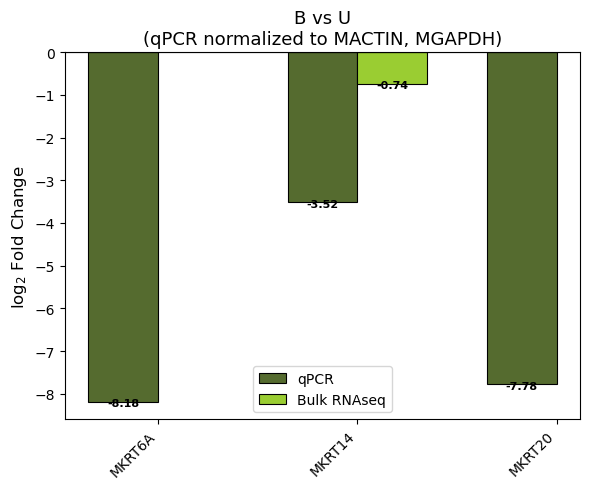

Saved as qpcr_vs_rnaseq_B_vs_U.png


In [13]:
pparg_genes = ['mNectin4', 'mPparg', 'mFabp4']
luminal_genes = ['mGata3', 'mFoxa1','mGrhl2']
basal_genes = ['mKrt6a','mKrt14','mKrt20']
epithelial_genes = ['mEcad','mEpcam']
macrophage_genes=['mCsf1']

plot_qpcr_vs_rnaseq_mice(qPCR_data, bulkRNA_data, hkg=['mactin','mgapdh'], 
                         reference_sample='U', 
                         test_sample='B', color1='darkolivegreen', color2='yellowgreen',
                         genes_to_include=basal_genes)